# Model A — MobileNetV2 (PyTorch): Accuracy Evaluation

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Configuration

In [2]:
# --- Paths ---
MODEL_PATH  = r'mobilenet_model.pth'
TEST_DIR    = r'..\Dataset\valid\images'   # sub-folders: Face / Non-Face

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
CLASS_NAMES = ['Face', 'Non-Face']          # must match folder names exactly

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
print(f'Model   : {os.path.abspath(MODEL_PATH)}')
print(f'Test dir: {os.path.abspath(TEST_DIR)}')

Device  : cpu
Model   : D:\Final Year\Sem 2\Major Project\Model Project\Model A (MobileNet)\mobilenet_model.pth
Test dir: D:\Final Year\Sem 2\Major Project\Model Project\Dataset\valid\images


## 2. Build & Load Model

The architecture **must exactly match** what was used during training (same as `app.py`):
- `MobileNetV2` backbone
- Classifier replaced with `[Dropout(0.2), Linear(last_channel → 2)]`

In [3]:
model = models.mobilenet_v2(weights=None)

# Rebuild the exact same classifier head used during training
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 2)
)

# Load saved weights
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(state_dict, strict=True)
model.to(device)
model.eval()

print('Model loaded and set to eval mode.')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Model loaded and set to eval mode.
Total parameters: 2,226,434


## 3. Load Test Data

In [4]:
# ImageNet normalization (same as used during MobileNetV2 training)
val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

test_dataset = ImageFolder(root=TEST_DIR, transform=val_transform)

# Verify class order matches CLASS_NAMES
print(f'Class to index mapping: {test_dataset.class_to_idx}')
assert list(test_dataset.class_to_idx.keys()) == CLASS_NAMES, \
    f'Class order mismatch! Expected {CLASS_NAMES}, got {list(test_dataset.class_to_idx.keys())}'

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Total images : {len(test_dataset)}')
print(f'Batches      : {len(test_loader)}')

Class to index mapping: {'Face': 0, 'Non-Face': 1}
Total images : 2000
Batches      : 63


## 4. Run Predictions

In [5]:
all_labels = []
all_probs  = []
all_preds  = []

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        outputs = model(images)                                        # raw logits
        probs   = torch.nn.functional.softmax(outputs, dim=1)         # probabilities
        preds   = torch.argmax(probs, dim=1)

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(test_loader):
            print(f'  Batch {batch_idx + 1}/{len(test_loader)} processed')

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)   # shape: (N, 2)

print(f'\nSamples predicted: {len(y_pred)}')

  Batch 10/63 processed
  Batch 20/63 processed
  Batch 30/63 processed
  Batch 40/63 processed
  Batch 50/63 processed
  Batch 60/63 processed
  Batch 63/63 processed

Samples predicted: 2000


## 5. Overall Accuracy & Classification Report

In [6]:
acc = accuracy_score(y_true, y_pred) * 100
print(f'\n=== Overall Accuracy: {acc:.2f}% ===\n')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


=== Overall Accuracy: 91.00% ===

              precision    recall  f1-score   support

        Face       0.94      0.88      0.91      1000
    Non-Face       0.89      0.94      0.91      1000

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



## 6. Confusion Matrix

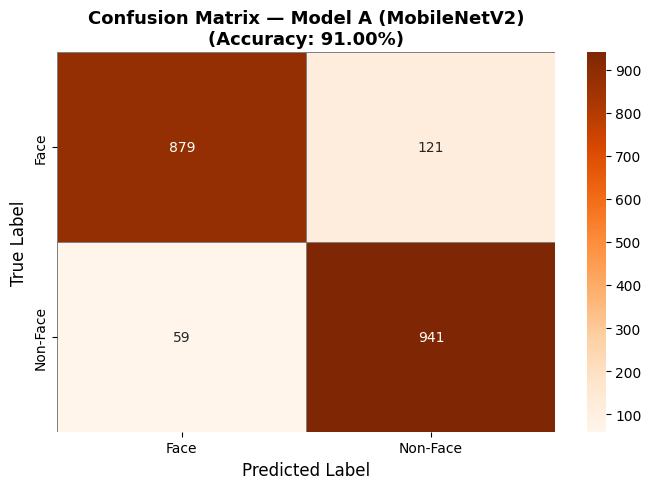

Saved: confusion_matrix.png


In [7]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(
    f'Confusion Matrix — Model A (MobileNetV2)\n(Accuracy: {acc:.2f}%)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

## 7. ROC Curve

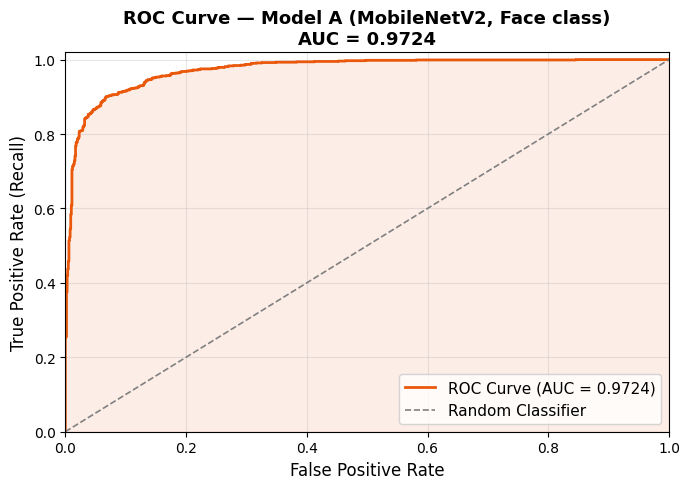

Saved: ROC.png


In [8]:
# ROC for the positive class: Face (index 0)
fpr, tpr, _ = roc_curve(y_true, y_prob[:, 0], pos_label=0)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#EA580C', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.10, color='#EA580C')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title(
    f'ROC Curve — Model A (MobileNetV2, Face class)\nAUC = {roc_auc:.4f}',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ROC.png', dpi=150)
plt.show()
print('Saved: ROC.png')

## 8. Summary

In [9]:
TP = cm[0, 0]; FN = cm[0, 1]; FP = cm[1, 0]; TN = cm[1, 1]
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('=' * 42)
print('  Model A - MobileNetV2 (PyTorch) Summary')
print('=' * 42)
print(f'  Accuracy  : {acc:.2f}%')
print(f'  Precision : {precision * 100:.2f}%  (Face class)')
print(f'  Recall    : {recall * 100:.2f}%  (Face class)')
print(f'  F1-Score  : {f1 * 100:.2f}%  (Face class)')
print(f'  AUC       : {roc_auc:.4f}')
print('=' * 42)
print(f'  TP={TP}  FP={FP}  FN={FN}  TN={TN}')
print('=' * 42)

  Model A - MobileNetV2 (PyTorch) Summary
  Accuracy  : 91.00%
  Precision : 93.71%  (Face class)
  Recall    : 87.90%  (Face class)
  F1-Score  : 90.71%  (Face class)
  AUC       : 0.9724
  TP=879  FP=59  FN=121  TN=941
